# Fine-Tuning DistilBERT for AG News Text Classification

**Repository:** `finetuning-distilbert-text-classification`  
**Task:** UAS Deep Learning — Fine-Tuning HuggingFace Models, Task 1  
**Architecture Type:** Encoder Transformer  
**Model:** `distilbert-base-uncased`  
**Dataset:** AG News  
**Problem Type:** Multi-class Text Classification

---

## 1. Learning Objectives

By the end of this notebook, you should be able to:

1. Build an end-to-end text classification pipeline using HuggingFace Transformers.
2. Load and inspect the AG News dataset.
3. Tokenize text using a DistilBERT tokenizer.
4. Fine-tune a pre-trained encoder model for 4-class news classification.
5. Evaluate the model using accuracy, macro F1-score, classification report, and confusion matrix.
6. Save the trained model and summarize the experiment results.

## 2. Theoretical Background

DistilBERT is a smaller and faster version of BERT created through knowledge distillation. It keeps the encoder-only Transformer structure but reduces model size, making fine-tuning more practical for limited GPU resources. For text classification, the model receives tokenized text, produces contextual embeddings, and uses a classification head to predict one of the target labels.

AG News is a four-class news categorization dataset. The target classes represent broad news topics: World, Sports, Business, and Sci/Tech. The task is supervised learning because every training example contains text and a known label.

The typical fine-tuning workflow is:

1. Load dataset.
2. Inspect labels and examples.
3. Tokenize text.
4. Load a pre-trained Transformer model.
5. Train/fine-tune on labeled data.
6. Evaluate on validation/test data.
7. Save model artifacts and report metrics.

## 3. Environment Setup

Run this cell in Google Colab or a local environment with GPU support. If the libraries are already installed, this step can be skipped.

In [ ]:
# If running in Google Colab, uncomment the following line:
# !pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib seaborn

## 4. Import Libraries and Set Configuration

This section imports the required Python libraries and defines configuration values used throughout the notebook.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
MODEL_NAME = "distilbert-base-uncased"
DATASET_NAME = "sh0416/ag_news"  # dataset link provided in the assignment
OUTPUT_DIR = "./distilbert-ag-news-checkpoints"
FINAL_MODEL_DIR = "./distilbert-ag-news-final"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Model:", MODEL_NAME)
print("Dataset:", DATASET_NAME)

Model: distilbert-base-uncased
Dataset: sh0416/ag_news


## 5. Load Dataset

The assignment provides the HuggingFace AG News dataset link. The notebook first attempts to load `sh0416/ag_news`. If the dataset mirror is unavailable, the standard HuggingFace `ag_news` dataset can be used as a fallback.

In [ ]:
try:
    dataset = load_dataset(DATASET_NAME)
except Exception as e:
    print("Primary dataset failed to load:", e)
    print("Falling back to standard ag_news dataset.")
    dataset = load_dataset("ag_news")

print(dataset)
print("Available splits:", dataset.keys())
print("Training example:")
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})
Available splits: dict_keys(['train', 'test'])
Training example:
{'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."}


## 6. Dataset Inspection

Before tokenization and training, inspect the dataset structure, label distribution, and a few examples. This is important because incorrect label mapping or column names can break the training pipeline or lead to wrong interpretation.

In [ ]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

# Convert dataset schema into a consistent format:
# Some AG News versions use columns: title + description
# Some standard versions use column: text
sample_df = pd.DataFrame(dataset["train"].select(range(min(1000, len(dataset["train"])))))

print("Original columns:", sample_df.columns.tolist())
print("Original label range:", sample_df["label"].min(), "to", sample_df["label"].max())

# Detect whether labels are 1-4 or 0-3
LABEL_OFFSET = 1 if sample_df["label"].min() == 1 and sample_df["label"].max() == 4 else 0
print("Detected LABEL_OFFSET:", LABEL_OFFSET)

def standardize_ag_news_schema(example):
    # Handle AG News versions with either "text" or "title" + "description"
    if "text" in example and example["text"] is not None:
        text = example["text"]
    else:
        title = example.get("title", "")
        description = example.get("description", "")
        text = (title + " " + description).strip()

    label = int(example["label"]) - LABEL_OFFSET

    return {
        "text": text,
        "label": label
    }

dataset = dataset.map(standardize_ag_news_schema)

train_df = pd.DataFrame(dataset["train"])

print(train_df.head())
print("\nColumns after standardization:", train_df.columns.tolist())
print("\nLabel distribution:")
print(train_df["label"].value_counts().sort_index().rename(index=dict(enumerate(label_names))))

for idx in range(3):
    example = dataset["train"][idx]
    print("\nExample", idx)
    print("Text:", example["text"][:300])
    print("Label:", example["label"], "->", label_names[example["label"]])


Original columns: ['label', 'title', 'description']
Original label range: 1 to 4
Detected LABEL_OFFSET: 1


   label                                              title  \
0      2  Wall St. Bears Claw Back Into the Black (Reuters)   
1      2  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      2    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      2  Iraq Halts Oil Exports from Main Southern Pipe...   
4      2  Oil prices soar to all-time record, posing new...   

                                         description  \
0  Reuters - Short-sellers, Wall Street's dwindli...   
1  Reuters - Private investment firm Carlyle Grou...   
2  Reuters - Soaring crude prices plus worries\ab...   
3  Reuters - Authorities have halted oil export\f...   
4  AFP - Tearaway world oil prices, toppling reco...   

                                                text  
0  Wall St. Bears Claw Back Into the Black (Reute...  
1  Carlyle Looks Toward Commercial Aerospace (Reu...  
2  Oil and Economy Cloud Stocks' Outlook (Reuters...  
3  Iraq Halts Oil Exports from Main Southern Pipe...  
4  Oil pr

## 7. Create Lightweight Training Subsets

Transformer fine-tuning can be computationally expensive. For a course project, the pipeline can be demonstrated with a smaller subset first. If more compute is available, increase `TRAIN_SIZE`, `VAL_SIZE`, and `TEST_SIZE` or use the full dataset.

In [ ]:
TRAIN_SIZE = 4000
VAL_SIZE = 1000
TEST_SIZE = 1000

# AG News has train and test splits. Create a validation set from train.
train_valid = dataset["train"].shuffle(seed=RANDOM_STATE)
small_train = train_valid.select(range(min(TRAIN_SIZE, len(train_valid))))
small_val = train_valid.select(range(min(TRAIN_SIZE, len(train_valid)), min(TRAIN_SIZE + VAL_SIZE, len(train_valid))))
small_test = dataset["test"].shuffle(seed=RANDOM_STATE).select(range(min(TEST_SIZE, len(dataset["test"]))))

print("Train size:", len(small_train))
print("Validation size:", len(small_val))
print("Test size:", len(small_test))

Train size: 4000
Validation size: 1000
Test size: 1000


## 8. Tokenization

DistilBERT cannot directly process raw text. The tokenizer converts text into token IDs, attention masks, and fixed-length input representations. Padding and truncation are required so examples in a batch have compatible shapes.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized_train = small_train.map(tokenize_function, batched=True)
tokenized_val = small_val.map(tokenize_function, batched=True)
tokenized_test = small_test.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_train[0].keys())
print("Tokenized sample input_ids length:", len(tokenized_train[0]["input_ids"]))

dict_keys(['label', 'title', 'description', 'text', 'input_ids', 'token_type_ids', 'attention_mask'])
Tokenized sample input_ids length: 35


## 9. Load Pre-Trained DistilBERT Model

The model is loaded with a sequence classification head. Because AG News has four classes, `num_labels=4` is required.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label={i: label for i, label in enumerate(label_names)},
    label2id={label: i for i, label in enumerate(label_names)}
)

print("Model loaded successfully.")
print("Number of labels:", model.config.num_labels)

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.
Number of labels: 4


## 10. Define Evaluation Metrics

Accuracy measures overall correctness, while macro F1 treats each class equally. Macro F1 is useful when we want balanced performance across all news categories.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    weighted_f1 = f1_score(labels, predictions, average="weighted")
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

## 11. Training Configuration

The configuration below is intentionally lightweight. For better final results, increase the number of epochs, use a larger subset or the full dataset, and train with GPU acceleration.

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to="none",
    seed=RANDOM_STATE
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer configured.")

Trainer configured.


## 12. Fine-Tune the Model

This step fine-tunes DistilBERT on the AG News subset. On Google Colab GPU, this may take several minutes depending on subset size and hardware availability.

In [ ]:
train_result = trainer.train()
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.383617,0.283212,0.911000,0.906436,0.910379
2,0.246487,0.259378,0.918000,0.913966,0.917628


TrainOutput(global_step=500, training_loss=0.38215471267700196, metrics={'train_runtime': 87.3642, 'train_samples_per_second': 91.571, 'train_steps_per_second': 5.723, 'total_flos': 188959064757120.0, 'train_loss': 0.38215471267700196, 'epoch': 2.0})


## 13. Evaluate on Validation and Test Sets

After training, evaluate the model on both validation and test sets. The validation set is used during model selection, while the test set gives a more final estimate of generalization.

In [ ]:
val_metrics = trainer.evaluate(tokenized_val)
test_metrics = trainer.evaluate(tokenized_test)

print("Validation metrics:")
print(val_metrics)
print("\nTest metrics:")
print(test_metrics)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.246487,0.259378,2,0.918000,0.913966,0.917628


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.246487,0.314908,2,0.899000,0.898809,0.898823


Validation metrics:
{'eval_loss': 0.2593781054019928, 'eval_accuracy': 0.918, 'eval_macro_f1': 0.9139660173160545, 'eval_weighted_f1': 0.9176280214377183}

Test metrics:
{'eval_loss': 0.3149084150791168, 'eval_accuracy': 0.899, 'eval_macro_f1': 0.898809400628384, 'eval_weighted_f1': 0.898822662472074}


## 14. Classification Report and Confusion Matrix

The confusion matrix shows which classes are confused with each other. The classification report gives precision, recall, and F1-score per class.

              precision    recall  f1-score   support

       World       0.94      0.85      0.89       266
      Sports       0.95      0.99      0.97       246
    Business       0.88      0.85      0.87       246
    Sci/Tech       0.83      0.91      0.87       242

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



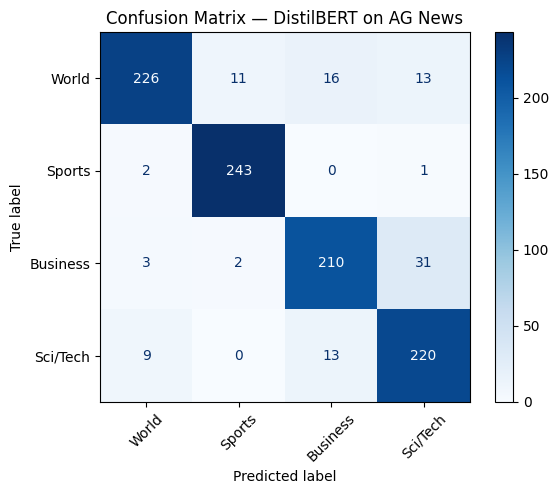

In [ ]:
predictions = trainer.predict(tokenized_test)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=label_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — DistilBERT on AG News")
plt.show()

## 15. Inference Demo

This section tests the fine-tuned model on custom news-like sentences. It demonstrates how the trained classifier can be used after fine-tuning.

In [ ]:
from transformers import pipeline

trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

classifier = pipeline("text-classification", model=FINAL_MODEL_DIR, tokenizer=FINAL_MODEL_DIR)

samples = [
    "The government announced a new international trade agreement after months of negotiation.",
    "The football club won the championship after a dramatic final match.",
    "The stock market rose after several technology companies reported strong earnings.",
    "Researchers introduced a new artificial intelligence chip for faster model training."
]

for text in samples:
    print("\nText:", text)
    print("Prediction:", classifier(text)[0])


Text: The government announced a new international trade agreement after months of negotiation.
Prediction: {'label': 'World', 'score': 0.633945643901825}

Text: The football club won the championship after a dramatic final match.
Prediction: {'label': 'Sports', 'score': 0.9496564865112305}

Text: The stock market rose after several technology companies reported strong earnings.
Prediction: {'label': 'Business', 'score': 0.9411174654960632}

Text: Researchers introduced a new artificial intelligence chip for faster model training.
Prediction: {'label': 'Sci/Tech', 'score': 0.9676756262779236}


## 16. Final Conclusion

This notebook demonstrates an end-to-end HuggingFace fine-tuning pipeline for text classification. The pipeline includes dataset loading, data inspection, tokenization, model fine-tuning, evaluation, confusion matrix analysis, inference, and report generation.

The main conclusion should be completed after running the notebook. In general, DistilBERT is a practical encoder model for classification because it balances performance and efficiency. If the test metrics are strong and the confusion matrix shows limited class confusion, the model can be considered effective for AG News topic classification.